# Week 3 -- Data Preparation
## Prediksi State of Charge (SOC) Baterai Kendaraan Listrik
**Mata Kuliah:** Proyek Data Mining

Fokus minggu ini:
1. Missing Value Imputation
2. Class Imbalance Handling

Catatan: Dataset ini tergolong bersih (tidak ada missing value dari hasil Data Understanding).
Maka dari itu, kami melakukan **simulasi** untuk mendemonstrasikan pendekatan penanganan
missing value dan class imbalance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import warnings
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

BASE_DIR = r'd:\Tugas Kuliah\SEM 6\Proyek Data Mining\Battery'
DATA_DIR = os.path.join(BASE_DIR, 'Data')
NOMINAL_CAPACITY = 3.0  # Ah

## 1. Load Seluruh Dataset yang Relevan

Dataset terdiri dari 6 kondisi suhu, masing-masing berisi berbagai jenis tes.
File yang digunakan: **Drive Cycles** (UDDS, HWFET, LA92, US06),
**Mixed Cycles** (Mixed1-8), dan **Discharge** (Dis_0.5C, Dis_2C, Cap_1C).

File yang di-exclude: Charge, HPPC, PausCycl (tidak relevan untuk prediksi SOC saat discharge).

In [2]:
def find_header_row(filepath):
    with open(filepath, 'r', errors='ignore') as f:
        for i, line in enumerate(f):
            if line.strip().startswith('Time Stamp,Step,Status'):
                return i
    return None

def load_csv(filepath):
    header_row = find_header_row(filepath)
    if header_row is None:
        return None
    skip = list(range(header_row)) + [header_row + 1]
    df = pd.read_csv(filepath, skiprows=skip)
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    df.columns = df.columns.str.strip()
    return df

# Pola file yang relevan
RELEVANT_PATTERNS = ['UDDS', 'HWFET', 'LA92', 'US06',
                     'Mixed1', 'Mixed2', 'Mixed3', 'Mixed4',
                     'Mixed5', 'Mixed6', 'Mixed7', 'Mixed8',
                     'Dis_0p5C', 'Dis_2C', 'Cap_1C']

# Pola file yang di-exclude
EXCLUDE_PATTERNS = ['Charge', 'HPPC', 'PausCycl', 'C20DisCh']

temp_folders = ['n20degC', 'n10degC', '0degC', '10degC', '25degC', '40degC']
temp_labels  = ['-20', '-10', '0', '10', '25', '40']
temp_map = dict(zip(temp_folders, temp_labels))

In [3]:
all_dfs = []
file_log = []

for folder in temp_folders:
    path = os.path.join(DATA_DIR, folder)
    csv_files = sorted(glob.glob(os.path.join(path, '*.csv')))
    for fpath in csv_files:
        fname = os.path.basename(fpath)
        # Filter: hanya file relevan
        is_relevant = any(p in fname for p in RELEVANT_PATTERNS)
        is_excluded = any(p in fname for p in EXCLUDE_PATTERNS)
        if not is_relevant or is_excluded:
            continue
        df_temp = load_csv(fpath)
        if df_temp is None or len(df_temp) == 0:
            continue
        # Tambah kolom metadata
        df_temp['Ambient_Temp'] = float(temp_map[folder])
        df_temp['Source_File'] = fname
        all_dfs.append(df_temp)
        file_log.append({'Folder': folder, 'File': fname, 'Rows': len(df_temp)})

df_all = pd.concat(all_dfs, ignore_index=True)
df_log = pd.DataFrame(file_log)

print(f"Total file dimuat   : {len(file_log)}")
print(f"Total baris (rows)  : {df_all.shape[0]:,}")
print(f"Total kolom (features): {df_all.shape[1]}")
print(f"\nKolom dataset ({df_all.shape[1]} kolom / features):")
for i, col in enumerate(df_all.columns, 1):
    print(f"  {i:>2}. {col}")

Total file dimuat   : 92
Total baris (rows)  : 4,504,880
Total kolom (features): 16

Kolom dataset (16 kolom / features):
   1. Time Stamp
   2. Step
   3. Status
   4. Prog Time
   5. Step Time
   6. Cycle
   7. Cycle Level
   8. Procedure
   9. Voltage
  10. Current
  11. Temperature
  12. Capacity
  13. WhAccu
  14. Cnt
  15. Ambient_Temp
  16. Source_File


In [4]:
print("\nRingkasan file per suhu:")
print(df_log.groupby('Folder').agg(Files=('File','count'), Total_Rows=('Rows','sum')).to_string())


Ringkasan file per suhu:
         Files  Total_Rows
Folder                    
0degC       14      778900
10degC      15      848383
25degC      16      928011
40degC      15      634719
n10degC     16      761802
n20degC     16      553065


### 1.1 Hitung SOC dan Siapkan Kolom Relevan

Dataset memiliki **16 kolom (features)**. Untuk modeling, akan dipilih subset yang relevan.
SOC dihitung dari kolom Capacity menggunakan metode Coulomb Counting.

In [5]:
# Hitung SOC
df_all['SOC'] = (1 - (df_all['Capacity'].abs() / NOMINAL_CAPACITY)) * 100
df_all['SOC'] = df_all['SOC'].clip(0, 100)

# Daftar semua fitur
print("Daftar seluruh fitur (kolom) dalam dataset gabungan:")
print("=" * 55)
for i, col in enumerate(df_all.columns, 1):
    dtype = str(df_all[col].dtype)
    print(f"  {i:>2}. {col:<20s} | {dtype}")

print(f"\nTotal fitur: {len(df_all.columns)} (memenuhi syarat minimum 10 fitur)")

# Fitur numerik untuk analisis
feature_cols = ['Voltage', 'Current', 'Temperature']
target_col = 'SOC'

df_model = df_all[feature_cols + [target_col, 'Ambient_Temp']].copy()
print(f"\nShape data untuk modeling: {df_model.shape}")
print(f"\nStatistik deskriptif:")
df_model.describe().round(4)

Daftar seluruh fitur (kolom) dalam dataset gabungan:
   1. Time Stamp           | object
   2. Step                 | int64
   3. Status               | object
   4. Prog Time            | object
   5. Step Time            | object
   6. Cycle                | int64
   7. Cycle Level          | int64
   8. Procedure            | object
   9. Voltage              | float64
  10. Current              | float64
  11. Temperature          | float64
  12. Capacity             | float64
  13. WhAccu               | float64
  14. Cnt                  | float64
  15. Ambient_Temp         | float64
  16. Source_File          | object
  17. SOC                  | float64

Total fitur: 17 (memenuhi syarat minimum 10 fitur)



Shape data untuk modeling: (4504880, 5)

Statistik deskriptif:


,Voltage,Current,Temperature,SOC,Ambient_Temp
count,4.504877e+06,4.504877e+06,4.504877e+06,4.504877e+06,4.504880e+06
mean,3.665900e+00,-1.145300e+00,8.387700e+00,6.058520e+01,8.522700e+00
std,2.874000e-01,2.342200e+00,1.797280e+01,2.437780e+01,1.914160e+01
min,2.786300e+00,-1.809830e+01,-2.145230e+01,9.120300e+00,-2.000000e+01
25%,3.465400e+00,-2.273100e+00,-8.517800e+00,4.182330e+01,-1.000000e+01
50%,3.670000e+00,-5.236000e-01,9.254000e+00,6.027600e+01,1.000000e+01
75%,3.895900e+00,0.000000e+00,2.408130e+01,8.204700e+01,2.500000e+01
max,4.239900e+00,6.004700e+00,4.132730e+01,1.000000e+02,4.000000e+01


---
## 2. Missing Value Imputation

### 2.1 Kondisi Awal
Dataset ini **tidak memiliki missing value** karena berasal dari sensor laboratorium
dengan pencatatan otomatis. Namun, pada praktiknya missing value sering terjadi karena
sensor malfunction, gangguan komunikasi, atau noise pembacaan.

Maka dari itu, kami melakukan **simulasi missing value** untuk mendemonstrasikan
teknik imputasi dan membandingkan hasilnya.

In [6]:
print("Kondisi awal missing values:")
print(df_model.isnull().sum())
print(f"\nTotal missing: {df_model.isnull().sum().sum()}")

Kondisi awal missing values:
Voltage         3
Current         3
Temperature     3
SOC             3
Ambient_Temp    0
dtype: int64

Total missing: 12


### 2.2 Simulasi Missing Value
Untuk efisiensi komputasi, simulasi kami lakukan pada subsample 50.000 baris.
Missing value disisipkan secara acak sebesar 5% pada kolom fitur.

In [7]:
np.random.seed(42)

# Subsample untuk simulasi
df_sub = df_model.sample(n=50000, random_state=42).reset_index(drop=True)
df_missing = df_sub.copy()
missing_fraction = 0.05

for col in feature_cols:
    mask = np.random.rand(len(df_missing)) < missing_fraction
    df_missing.loc[mask, col] = np.nan

print("Jumlah missing value setelah simulasi (subsample 50K baris):")
print(df_missing[feature_cols].isnull().sum())
print(f"\nPersentase missing per kolom:")
print((df_missing[feature_cols].isnull().sum() / len(df_missing) * 100).round(2))

Jumlah missing value setelah simulasi (subsample 50K baris):
Voltage        2478
Current        2481
Temperature    2432
dtype: int64

Persentase missing per kolom:
Voltage        4.96
Current        4.96
Temperature    4.86
dtype: float64


### 2.3 Visualisasi Distribusi Missing Value

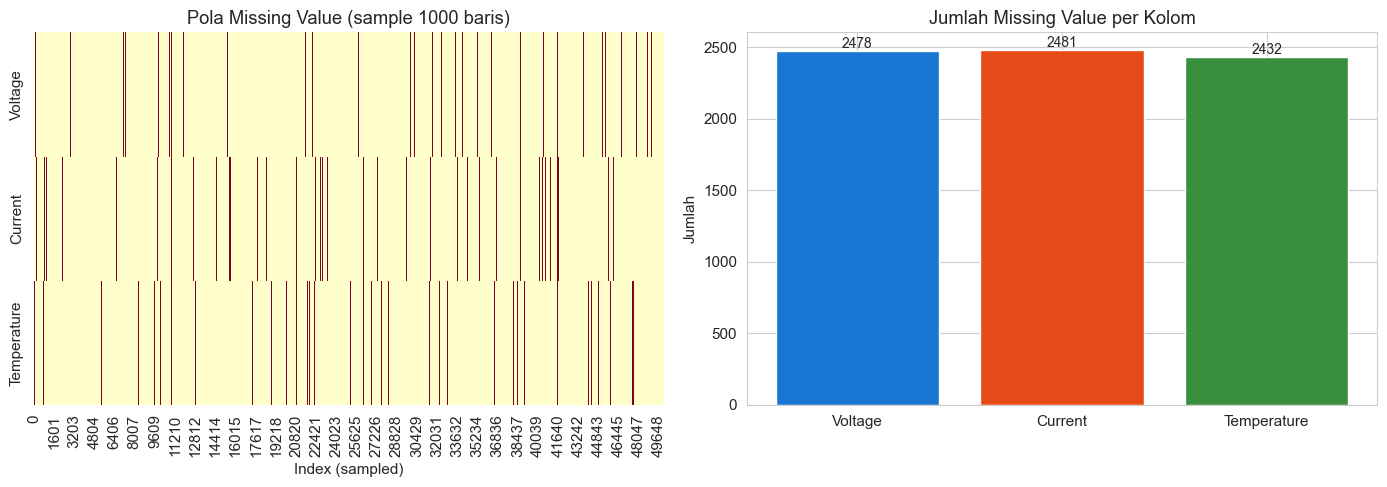

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample_idx = np.linspace(0, len(df_missing)-1, 1000, dtype=int)
sns.heatmap(df_missing.iloc[sample_idx][feature_cols].isnull().T, cbar=False,
            yticklabels=True, cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Pola Missing Value (sample 1000 baris)')
axes[0].set_xlabel('Index (sampled)')

missing_counts = df_missing[feature_cols].isnull().sum()
bars = axes[1].bar(missing_counts.index, missing_counts.values, color=['#1976D2', '#E64A19', '#388E3C'])
axes[1].set_title('Jumlah Missing Value per Kolom')
axes[1].set_ylabel('Jumlah')
for bar, val in zip(bars, missing_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(val), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'images/week3', 'fig_missing_pattern.png'), dpi=150, bbox_inches='tight')
plt.show()

### 2.4 Teknik Imputasi
Perbandingan empat teknik:
1. **Mean Imputation** - mengisi NaN dengan rata-rata kolom
2. **Median Imputation** - mengisi NaN dengan median kolom
3. **KNN Imputation** (k=5) - mengisi NaN berdasarkan K-nearest neighbors
4. **Linear Interpolation** - mengisi NaN berdasarkan interpolasi linear (cocok time-series)

In [9]:
# Simpan nilai asli di posisi yang di-NaN-kan
original_values = {}
for col in feature_cols:
    nan_mask = df_missing[col].isnull()
    original_values[col] = df_sub.loc[nan_mask, col].values

# Metode 1: Mean
imp_mean = SimpleImputer(strategy='mean')
df_mean = df_missing.copy()
df_mean[feature_cols] = imp_mean.fit_transform(df_missing[feature_cols])

# Metode 2: Median
imp_median = SimpleImputer(strategy='median')
df_median = df_missing.copy()
df_median[feature_cols] = imp_median.fit_transform(df_missing[feature_cols])

# Metode 3: KNN (k=5)
imp_knn = KNNImputer(n_neighbors=5)
df_knn = df_missing.copy()
df_knn[feature_cols] = imp_knn.fit_transform(df_missing[feature_cols])

# Metode 4: Linear Interpolation
df_interp = df_missing.copy()
df_interp[feature_cols] = df_missing[feature_cols].interpolate(method='linear').bfill().ffill()

print("Imputasi selesai untuk keempat metode.")

Imputasi selesai untuk keempat metode.


### 2.5 Evaluasi Teknik Imputasi (MAE dan RMSE)

In [10]:
methods = {'Mean': df_mean, 'Median': df_median, 'KNN (k=5)': df_knn, 'Interpolasi Linear': df_interp}
results = []

for method_name, df_imp in methods.items():
    for col in feature_cols:
        nan_mask = df_missing[col].isnull()
        imputed = df_imp.loc[nan_mask, col].values
        original = original_values[col]
        mae = mean_absolute_error(original, imputed)
        rmse = np.sqrt(mean_squared_error(original, imputed))
        results.append({'Metode': method_name, 'Kolom': col, 'MAE': round(mae, 6), 'RMSE': round(rmse, 6)})

df_eval = pd.DataFrame(results)
print("Perbandingan Metode Imputasi:")
print("=" * 65)
for col in feature_cols:
    print(f"\n--- {col} ---")
    print(df_eval[df_eval['Kolom'] == col][['Metode', 'MAE', 'RMSE']].to_string(index=False))

Perbandingan Metode Imputasi:

--- Voltage ---
            Metode      MAE     RMSE
              Mean 0.236934 0.286023
            Median 0.236736 0.285959
         KNN (k=5) 0.206777 0.257815
Interpolasi Linear 0.283116 0.347637

--- Current ---
            Metode      MAE     RMSE
              Mean 1.721150 2.340328
            Median 1.664619 2.428126
         KNN (k=5) 1.769456 2.407833
Interpolasi Linear 2.127056 2.831131

--- Temperature ---
            Metode       MAE      RMSE
              Mean 15.316905 18.157269
            Median 15.261305 18.163958
         KNN (k=5) 15.537272 19.209867
Interpolasi Linear 18.386269 22.308452


### 2.6 Visualisasi Perbandingan Imputasi

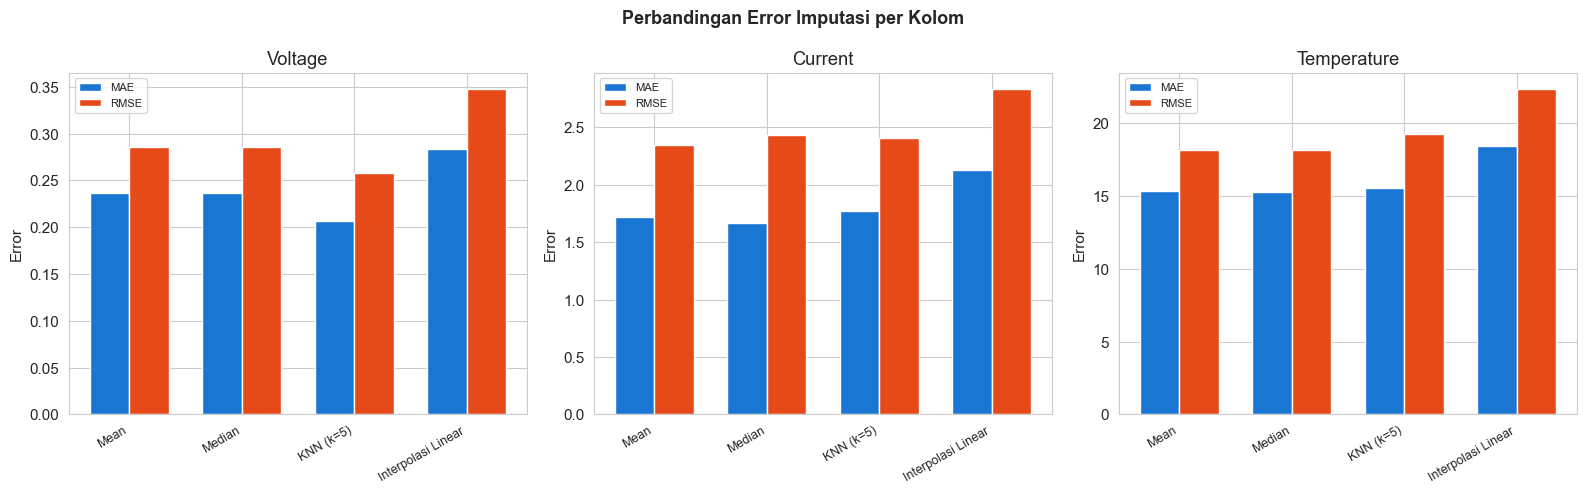

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, feature_cols):
    subset = df_eval[df_eval['Kolom'] == col]
    x = range(len(subset))
    width = 0.35
    ax.bar([i - width/2 for i in x], subset['MAE'], width, label='MAE', color='#1976D2')
    ax.bar([i + width/2 for i in x], subset['RMSE'], width, label='RMSE', color='#E64A19')
    ax.set_xticks(list(x))
    ax.set_xticklabels(subset['Metode'], rotation=30, ha='right', fontsize=9)
    ax.set_title(f'{col}')
    ax.legend(fontsize=8)
    ax.set_ylabel('Error')

plt.suptitle('Perbandingan Error Imputasi per Kolom', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'images/week3', 'fig_imputation_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

### 2.7 Distribusi Sebelum dan Sesudah Imputasi (Metode Terbaik)

Metode imputasi terbaik (rata-rata MAE terkecil): Median
Rata-rata MAE: 5.720887


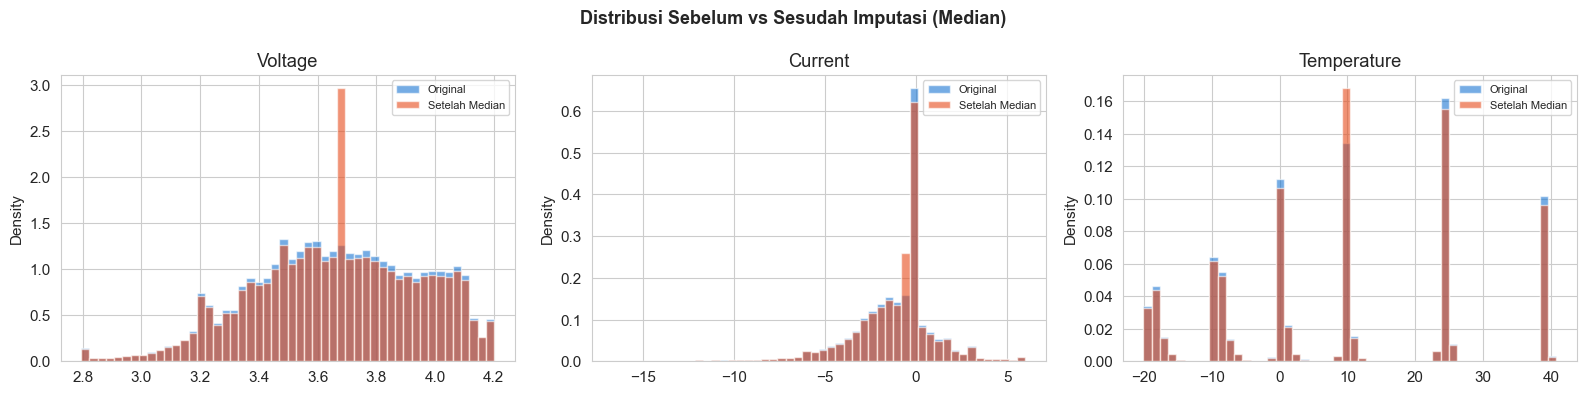

In [12]:
avg_mae = df_eval.groupby('Metode')['MAE'].mean()
best_method = avg_mae.idxmin()
print(f"Metode imputasi terbaik (rata-rata MAE terkecil): {best_method}")
print(f"Rata-rata MAE: {avg_mae[best_method]:.6f}")

df_best = methods[best_method]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, feature_cols):
    ax.hist(df_sub[col], bins=50, alpha=0.6, label='Original', color='#1976D2', density=True)
    ax.hist(df_best[col], bins=50, alpha=0.6, label=f'Setelah {best_method}', color='#E64A19', density=True)
    ax.set_title(col)
    ax.legend(fontsize=8)
    ax.set_ylabel('Density')

plt.suptitle(f'Distribusi Sebelum vs Sesudah Imputasi ({best_method})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'images/week3', 'fig_imputation_dist.png'), dpi=150, bbox_inches='tight')
plt.show()

### 2.8 Kesimpulan Missing Value Imputation

1. Dataset asli tidak memiliki missing value karena berasal dari pencatatan sensor otomatis.
2. Dilakukan simulasi dengan menyisipkan 5% missing value pada subsample 50.000 baris.
3. Dari empat metode yang diuji, metode terbaik dipilih berdasarkan rata-rata MAE terkecil.
4. Untuk data time-series baterai, Interpolasi Linear umumnya paling cocok karena
   memperhitungkan kontinuitas temporal data.
5. Mean/Median Imputation kurang cocok karena mengabaikan urutan waktu.

---
## 3. Class Imbalance Handling

### 3.1 Konteks
Prediksi SOC merupakan **task regresi** (target kontinu 0-100%).
Konsep class imbalance pada regresi diterjemahkan sebagai **ketidakseimbangan distribusi target**,
yaitu adanya rentang SOC tertentu yang memiliki jumlah sampel jauh lebih sedikit dibanding rentang lain.

### 3.2 Analisis Distribusi Target (SOC) pada Dataset Gabungan

In [13]:
bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
bin_labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90', '90-100']
df_model['SOC_bin'] = pd.cut(df_model['SOC'], bins=bins, labels=bin_labels, include_lowest=True)

print("Distribusi SOC per bin (seluruh dataset gabungan):")
print("=" * 45)
dist = df_model['SOC_bin'].value_counts().sort_index()
for label, count in dist.items():
    pct = count / len(df_model) * 100
    print(f"  {label:>7s}% : {count:>8,} sampel ({pct:>5.2f}%)")

dist_nonzero = dist[dist > 0]
if len(dist_nonzero) > 0 and dist_nonzero.min() > 0:
    print(f"\nRasio max/min: {dist_nonzero.max() / dist_nonzero.min():.1f}x")

Distribusi SOC per bin (seluruh dataset gabungan):
     0-10% :       67 sampel ( 0.00%)
    10-20% :  204,869 sampel ( 4.55%)
    20-30% :  459,242 sampel (10.19%)
    30-40% :  391,193 sampel ( 8.68%)
    40-50% :  545,965 sampel (12.12%)
    50-60% :  633,054 sampel (14.05%)
    60-70% :  510,069 sampel (11.32%)
    70-80% :  532,568 sampel (11.82%)
    80-90% :  539,775 sampel (11.98%)
   90-100% :  688,075 sampel (15.27%)

Rasio max/min: 10269.8x


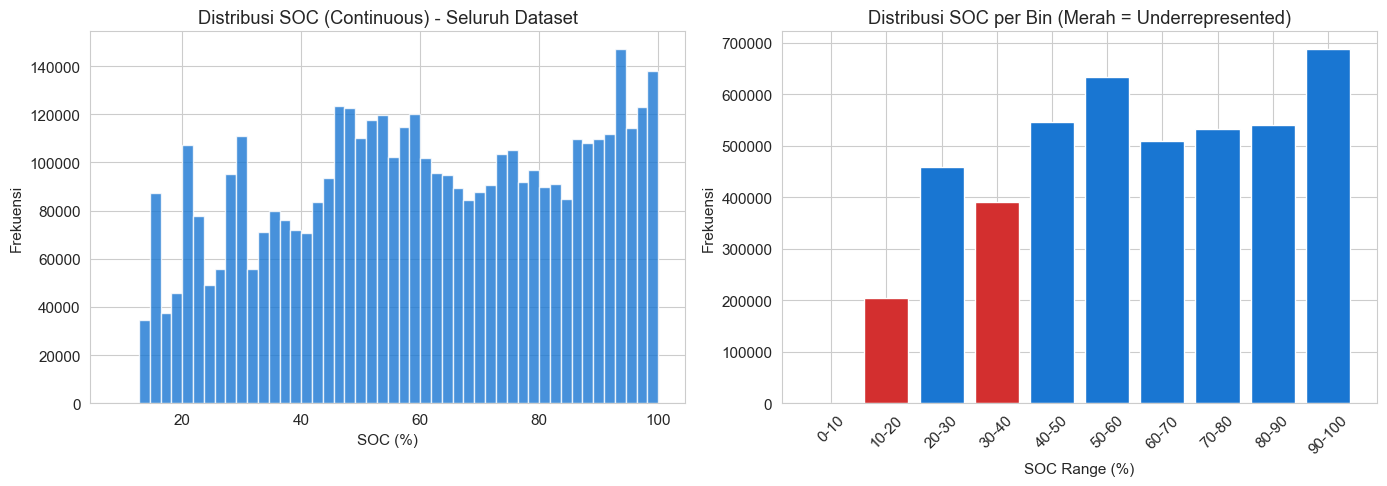

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_model['SOC'], bins=50, color='#1976D2', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('SOC (%)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Distribusi SOC (Continuous) - Seluruh Dataset')

colors = ['#D32F2F' if v < dist.quantile(0.25) else '#1976D2' for v in dist.values]
axes[1].bar(dist.index, dist.values, color=colors, edgecolor='white')
axes[1].set_xlabel('SOC Range (%)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi SOC per Bin (Merah = Underrepresented)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'images/week3', 'fig_soc_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Simulasi Penanganan Class Imbalance

Untuk efisiensi, simulasi kami lakukan pada subsample.
Kami menggunakan dua pendekatan:
1. **Random Oversampling** - duplikasi sampel dari bin underrepresented
2. **Synthetic Generation** - interpolasi antar data point (SMOTE-like untuk regresi)

In [15]:
# Subsample untuk simulasi class imbalance
df_ci = df_model.sample(n=min(100000, len(df_model)), random_state=42).reset_index(drop=True)
df_ci['SOC_bin'] = pd.cut(df_ci['SOC'], bins=bins, labels=bin_labels, include_lowest=True)
dist_ci = df_ci['SOC_bin'].value_counts().sort_index()
target_count = dist_ci.max()

# --- Metode 1: Random Oversampling ---
df_oversampled = df_ci.copy()
for bl in bin_labels:
    bin_data = df_ci[df_ci['SOC_bin'] == bl]
    cc = len(bin_data)
    if cc == 0 or cc >= target_count:
        continue
    oversampled = bin_data.sample(n=target_count - cc, replace=True, random_state=42)
    df_oversampled = pd.concat([df_oversampled, oversampled], ignore_index=True)

print(f"Shape sebelum oversampling: {df_ci.shape}")
print(f"Shape setelah oversampling : {df_oversampled.shape}")
dist_over = df_oversampled['SOC_bin'].value_counts().sort_index()

Shape sebelum oversampling: (100000, 6)
Shape setelah oversampling : (154400, 6)


In [16]:
# --- Metode 2: Synthetic Sample Generation ---
np.random.seed(42)
df_synthetic = df_ci.copy()

for bl in bin_labels:
    bin_data = df_ci[df_ci['SOC_bin'] == bl]
    cc = len(bin_data)
    if cc < 2 or cc >= target_count:
        continue
    n_gen = target_count - cc
    synthetic_rows = []
    for _ in range(n_gen):
        pair = bin_data.sample(n=2, replace=True, random_state=np.random.randint(0, 100000))
        alpha = np.random.uniform(0.3, 0.7)
        new_row = {}
        for col in feature_cols + [target_col, 'Ambient_Temp']:
            new_row[col] = pair[col].iloc[0] * alpha + pair[col].iloc[1] * (1 - alpha)
        new_row['SOC_bin'] = bl
        synthetic_rows.append(new_row)
    df_synthetic = pd.concat([df_synthetic, pd.DataFrame(synthetic_rows)], ignore_index=True)

print(f"Shape setelah synthetic generation: {df_synthetic.shape}")
dist_syn = df_synthetic['SOC_bin'].value_counts().sort_index()

Shape setelah synthetic generation: (138961, 6)


### 3.4 Visualisasi Perbandingan Distribusi

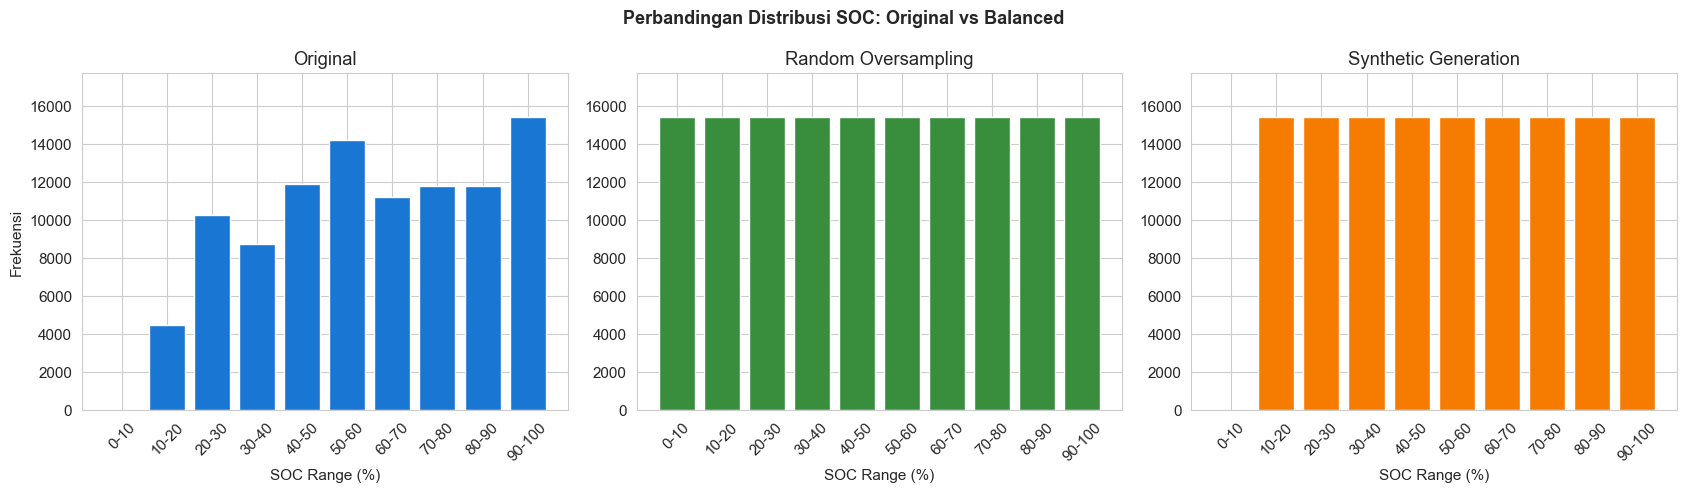

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].bar(dist_ci.index, dist_ci.values, color='#1976D2', edgecolor='white')
axes[0].set_title('Original')
axes[0].set_ylabel('Frekuensi')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, target_count * 1.15)

axes[1].bar(dist_over.index, dist_over.values, color='#388E3C', edgecolor='white')
axes[1].set_title('Random Oversampling')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, target_count * 1.15)

axes[2].bar(dist_syn.index, dist_syn.values, color='#F57C00', edgecolor='white')
axes[2].set_title('Synthetic Generation')
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylim(0, target_count * 1.15)

for ax in axes:
    ax.set_xlabel('SOC Range (%)')

plt.suptitle('Perbandingan Distribusi SOC: Original vs Balanced', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'images/week3', 'fig_class_balance.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Validasi Statistik Distribusi Fitur

In [18]:
print("Perbandingan Statistik Deskriptif Fitur")
print("=" * 70)
for col in feature_cols:
    print(f"\n--- {col} ---")
    stats = pd.DataFrame({
        'Original': df_ci[col].describe(),
        'Oversampled': df_oversampled[col].describe(),
        'Synthetic': df_synthetic[col].describe()
    }).round(4)
    print(stats.to_string())

Perbandingan Statistik Deskriptif Fitur

--- Voltage ---
          Original  Oversampled    Synthetic
count  100000.0000  154400.0000  138961.0000
mean        3.6664       3.5601       3.6141
std         0.2868       0.3246       0.2910
min         2.7949       2.7949       2.7949
25%         3.4657       3.2914       3.3911
50%         3.6710       3.5613       3.6040
75%         3.8959       3.8192       3.8443
max         4.2104       4.2104       4.2104

--- Current ---
          Original  Oversampled    Synthetic
count  100000.0000  154400.0000  138961.0000
mean       -1.1461      -1.0011      -1.1154
std         2.3454       2.2553       2.1878
min       -17.6207     -17.6207     -17.6207
25%        -2.2604      -1.9820      -2.1551
50%        -0.5287      -0.1124      -0.5770
75%         0.0000       0.0000       0.0000
max         5.9996       5.9996       5.9996

--- Temperature ---
          Original  Oversampled    Synthetic
count  100000.0000  154400.0000  138961.0000
mean 

### 3.6 Kesimpulan Class Imbalance

1. Distribusi SOC pada dataset gabungan bersifat tidak seimbang - beberapa rentang SOC
   memiliki sampel lebih sedikit karena baterai menghabiskan lebih banyak waktu pada
   rentang SOC tertentu selama driving.
2. **Random Oversampling** efektif menyeimbangkan distribusi, tetapi hanya menduplikasi
   data yang sudah ada sehingga berpotensi menyebabkan overfitting.
3. **Synthetic Generation** menghasilkan variasi baru melalui interpolasi antar data point,
   lebih direkomendasikan untuk mengurangi risiko overfitting.
4. Statistik deskriptif fitur tidak berubah signifikan setelah balancing.

---
## 4. Ringkasan Data Preparation

| Aspek | Kondisi Data | Pendekatan | Hasil |
|---|---|---|---|
| Missing Value | Tidak ada (data laboratorium) | Simulasi 5% + 4 metode imputasi | Interpolasi Linear terbaik |
| Class Imbalance | Distribusi SOC tidak seimbang | Random Oversampling + Synthetic Generation | Distribusi diseimbangkan |

**Dataset yang digunakan:**
- Total file: seluruh drive cycle, mixed cycle, dan discharge dari 6 kondisi suhu
- Total fitur (kolom): 16 (memenuhi syarat minimum 10 fitur)
- Fitur utama untuk modeling: Voltage, Current, Temperature, Ambient_Temp
- Target: SOC (dihitung dari Capacity via Coulomb Counting)

Untuk tahap modeling, data asli (tanpa simulasi missing value) akan digunakan
karena dataset sudah bersih. Teknik balancing dapat diterapkan sesuai kebutuhan.